# Using Graph Neural Networks for Site-of-Metabolism Prediction and its Applications to Ranking Promiscuous Enzymatic Products

This notebook demonstrates usage of the GNN-SOM models for site-of-metabolism prediction.

In [9]:
import json
from os.path import isfile

import torch
from torch_geometric.data import Data
from rdkit.Chem import Draw
import requests

from IPython.display import SVG

from gnn_som import createGnnSom, loadGnnSomState
from gnn_som.MolFromKcf import MolFromKcfFile

import os

os.environ['CUDA_VISIBLE_DEVICES'] = "1"

from rdkit import Chem
from rdkit.Chem import AllChem

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load configuration file. This file describes feature mappings as well as various model parameters needed to bring them up.

In [11]:
with open('data/config.json', 'r') as f:
    config = json.load(f)
config['features']['enzyme'] = [tuple(ec) for ec in config['features']['enzyme']] 

Configure several variants of the model, each was trained on a different data split and all will contribute to the final SOM prediction.

In [12]:
models = []
for i, params in enumerate(config['models']):
    model = createGnnSom(*config['models'][i])
    loadGnnSomState(model, torch.load('data/model%d.pt' % i, map_location=torch.device('cpu')))
    models.append(model)

/tmp/ipykernel_223548/2363953424.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loadGnnSomState(model, torch.load('data/model%d.pt' % i, map_location=torch.device('cpu'

Load the query molecule and select the enzyme. In this example, we evaluate interaction between compound [C00355](https://www.genome.jp/entry/C00355) and enzyme [1.10.3.1](https://www.genome.jp/entry/1.10.3.1), which corresponds to the right side of rpair RP00123.

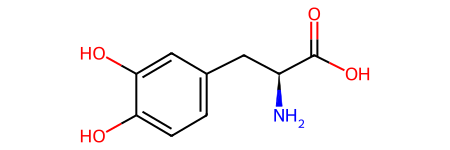

In [5]:
molecule = 'C00355'
enzyme = (1, 10)
if not isfile(molecule + '.kcf'):
    with open(molecule + '.kcf', 'wb') as f:
        f.write(requests.get('https://www.genome.jp/entry/-f+k+' + molecule).content)
mol = MolFromKcfFile(molecule + '.kcf')
mol

The `mol` object in this example is an RDKit molecule, as such any format supported by RDKit could be used as an input also. However, because our model uses KEGG atom types, they must be provided as atom property `kcfType`. One way this can be accomplished is by converting the RDKit molecule to KCF format using the KEGG mol2kcf tool and then importing the result using the `MolFromKcfContents()` function. For example, if the molecule definition is available as a SMILES string, the following code could be used instead:

```py
from io import BytesIO
from rdkit import Chem
from gnn_som.MolFromKcf import MolFromKcfContents

mol = Chem.MolFromSmiles('C1=CC(=C(C=C1CC(C(=O)O)N)O)O')
molFile = BytesIO(Chem.MolToMolBlock(mol).encode('ascii'))
kcf = requests.post('http://rest.genome.jp/mol2kcf/', files={'molfile': molFile}).content.decode('ascii')
mol = MolFromKcfContents(kcf)
```

Thanks to Rafael [@rflameiro](https://github.com/rflameiro) for suggesting this approach!

Construct a graph representation of the molecule, which includes atom feature vectors and bond connectivity.

In [21]:
smi = 'C[C@@H]1CC[C@H]2[C@@H](C)[C@H](OC(=O)CCC(=O)O)O[C@@H]3O[C@@]4(C)CC[C@@H]1[C@@]23OO4'
molecule = Chem.MolFromSmiles(smi)
molecule = Chem.AddHs(molecule)

# Compute 2D coordenates and write to .mol file
AllChem.Compute2DCoords(molecule)
if os.path.exists("molecule.mol"):
    os.remove("molecule.mol")
print(Chem.MolToMolBlock(molecule), file=open("molecule.mol", 'a+'))

if os.path.exists("molecule.kcf"):
    os.remove("molecule.kcf")

# Convert .mol to .kcf (KEGG format used in the paper) 
# https://iwatobipen.wordpress.com/2016/12/23/convert-chemical-file-format/
# https://www.genome.jp/tools/gn_ca_tools_api.html
!curl -F molfile=@molecule.mol http://rest.genome.jp/mol2kcf/ > molecule.kcf



# Define mol
mol = MolFromKcfFile('molecule.kcf')
enzyme = (1,14)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7167    0  2034  100  5133   3129   7896 --:--:-- --:--:-- --:--:-- 11026


In [22]:
numFeatures = sum(len(feature) for feature in config['features'].values())
x = torch.zeros((mol.GetNumAtoms(), numFeatures), dtype=torch.float32)
for atom in mol.GetAtoms():
    x[atom.GetIdx(), config['features']['enzyme'].index(enzyme)] = 1
    offset = len(config['features']['enzyme'])
    x[atom.GetIdx(), offset + config['features']['element'].index(atom.GetSymbol())] = 1
    offset += len(config['features']['element'])
    x[atom.GetIdx(), offset + config['features']['kcfType'].index(atom.GetProp('kcfType'))] = 1

edgeIndex = torch.zeros((2, mol.GetNumBonds() * 2), dtype=torch.int64)
for bond in mol.GetBonds():
    i = bond.GetIdx()
    edgeIndex[0][i * 2] = bond.GetBeginAtomIdx()
    edgeIndex[1][i * 2] = bond.GetEndAtomIdx()
    edgeIndex[0][i * 2 + 1] = bond.GetEndAtomIdx()
    edgeIndex[1][i * 2 + 1] = bond.GetBeginAtomIdx()

data = Data(x=x, edgeIndex=edgeIndex)
data

Data(x=[27, 157], edgeIndex=[2, 60])

Predict SOM labels using multiple models and retain the average value for each atom.

In [23]:
# 确保模型和数据都在同一设备上运行
data = data.to(device)  # 将数据移动到 GPU 或保持在 CPU
y = None

for model in models:
    model = model.to(device)  # 将每个模型移动到 GPU（如果尚未移动）
    newY = torch.sigmoid(model(data.x, data.edgeIndex))  # 数据已在 GPU 或 CPU 上
    y = newY if y is None else torch.add(y, newY)

# 计算模型平均输出
y = torch.div(y, len(models))
print(y.shape)

torch.Size([27, 1])


In [24]:
import torch

# 假设 scores 是你的 torch 张量，大小是 [14, 1]
scores = y  # 示例：14个原子的反应分数，实际使用时替换为你的数据

# 创建一个空字典来存储原子序号和对应的分数
atom_scores = {}

# 将分数映射到原子序号
for idx, score in enumerate(scores):
    atom_scores[idx] = score.item()  # 使用 item() 将张量转换为标量

# 打印结果
print(atom_scores)


{0: 0.22254441678524017, 1: 0.2501141130924225, 2: 0.4828106462955475, 3: 0.5830352902412415, 4: 0.5257073044776917, 5: 0.03095928765833378, 6: 0.018044298514723778, 7: 0.08931071311235428, 8: 0.059467971324920654, 9: 0.009247701615095139, 10: 0.004362399224191904, 11: 0.01653577759861946, 12: 0.06028161197900772, 13: 0.0040538073517382145, 14: 0.026584764942526817, 15: 0.18711626529693604, 16: 0.518359363079071, 17: 0.42793479561805725, 18: 0.0916891023516655, 19: 0.045765940099954605, 20: 0.03499438613653183, 21: 0.014747293666005135, 22: 0.023309381678700447, 23: 0.04194669798016548, 24: 0.03451899439096451, 25: 0.13676099479198456, 26: 0.07136744260787964}


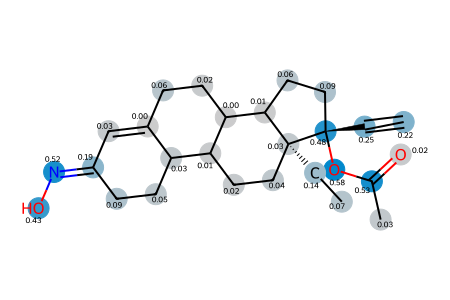

In [25]:
def hsvToRgb(h, s, v):
    c = v * s
    h /= 60.0
    x = c * (1 - abs(h % 2 - 1))
    if 0 <= h < 1:
        r, g, b = (c, x, 0)
    elif 1 <= h < 2:
        r, g, b = (x, c, 0)
    elif 2 <= h < 3:
        r, g, b = (0, c, x)
    elif 3 <= h < 4:
        r, g, b = (0, x, c)
    elif 4 <= h < 5:
        r, g, b = (x, 0, c)
    else:
        r, g, b = (c, 0, x)
    m = v - c
    return (r + m, g + m, b + m)
        
highlights = {}
highlightRadii = {}
minY = torch.min(y).item()
maxY = torch.max(y).item()
for atom in mol.GetAtoms():
    label = y[atom.GetIdx()].item()
    atom.SetProp('atomNote', '%.2f' % label)
    highlights[atom.GetIdx()] = [hsvToRgb(200, (label - minY) / (maxY - minY), 0.8)]
    highlightRadii[atom.GetIdx()] = 0.4

dwg = Draw.MolDraw2DSVG(450, 300)
opt = dwg.drawOptions()
opt.atomHighlightsAreCircles = True
dwg.DrawMoleculeWithHighlights(mol, '', highlights, {}, highlightRadii, {})
dwg.FinishDrawing()
SVG(dwg.GetDrawingText().replace('svg:', ''))


In [18]:
def hsvToRgb(h, s, v):
    c = v * s
    h /= 60.0
    x = c * (1 - abs(h % 2 - 1))
    if 0 <= h < 1:
        r, g, b = (c, x, 0)
    elif 1 <= h < 2:
        r, g, b = (x, c, 0)
    elif 2 <= h < 3:
        r, g, b = (0, c, x)
    elif 3 <= h < 4:
        r, g, b = (0, x, c)
    elif 4 <= h < 5:
        r, g, b = (x, 0, c)
    else:
        r, g, b = (c, 0, x)
    m = v - c
    return (r + m, g + m, b + m)

highlights = {}
highlightRadii = {}
minY = torch.min(y).item()
maxY = torch.max(y).item()

# 用于存储归一化值
normalized_values = {}

for atom in mol.GetAtoms():
    label = y[atom.GetIdx()].item()
    normalized_value = (label - minY) / (maxY - minY)  # 计算归一化值
    normalized_values[atom.GetIdx()] = normalized_value  # 存储到字典
    atom.SetProp('atomNote', '%.2f' % label)
    highlights[atom.GetIdx()] = [hsvToRgb(200, normalized_value, 0.8)]  # 使用归一化值
    highlightRadii[atom.GetIdx()] = 0.4

dwg = Draw.MolDraw2DSVG(450, 300)
opt = dwg.drawOptions()
opt.atomHighlightsAreCircles = True
dwg.DrawMoleculeWithHighlights(mol, '', highlights, {}, highlightRadii, {})
dwg.FinishDrawing()
SVG(dwg.GetDrawingText().replace('svg:', ''))

# 输出或使用归一化值
print(normalized_values)


{0: 0.16750823424096756, 1: 0.02411083223811648, 2: 0.006794152795402368, 3: 0.0013229982599398248, 4: 0.0009722993595056247, 5: 0.0006084019953739664, 6: 0.004183403411121787, 7: 0.20922137751453893, 8: 0.07070980833501325, 9: 0.14959706915327864, 10: 0.014546961853476158, 11: 0.06409293802141763, 12: 0.040848106425341014, 13: 0.10505576473359314, 14: 0.08701908953586958, 15: 0.42945004320693175, 16: 0.02287787028930762, 17: 0.07042865704570472, 18: 0.004579867958051097, 19: 0.020254864290451244, 20: 0.014997740853257481, 21: 0.05613284754463947, 22: 0.0077383550628224934, 23: 0.006921286137116183, 24: 0.007286707728623779, 25: 0.0024287287911607448, 26: 0.007204197052779073, 27: 0.0765765403456004, 28: 0.050613827424860605, 29: 0.1439899893901262, 30: 0.1899268193052716, 31: 0.08867749753681461, 32: 0.21851749839954132, 33: 0.2987436687690758, 34: 0.20813078189691225, 35: 0.20434131107995734, 36: 0.05250462494350742, 37: 0.06546749384839663, 38: 0.010503252037161338, 39: 0.0099546496